# Temporal-pattern discrimination — single neuron, single session (U2)

Instead of reducing each trial to one scalar spike count (the approach in `neuron_behavior_analysis.ipynb`), this notebook keeps each trial's full **temporal firing-rate trajectory** (spike counts in 50ms bins, from trial start to 2s post-trial-start) and asks: how well does that whole trajectory — not a window sum, not an isolated per-bin snapshot — discriminate between pairs of stimuli or pairs of outcomes?

Method: for a given neuron and a given pair of conditions, treat each trial's binned firing-rate vector as a feature vector, fit a cross-validated L2-regularized logistic regression classifier to discriminate the two conditions, and score it by AUC (0.5 = chance, 1.0 = perfect). Significance is assessed via a label-permutation test. Repeating this over all pairs within a variable family (unilateral stimuli, bilateral stimuli, outcome) gives a per-neuron pairwise discriminability matrix.

Scope: stimuli and outcome only — continuous variables (run speed, whisker angle/curvature) are excluded from this pass.

## 1. Config

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib widget
from scipy.stats import spearmanr

from tools.load_session import load_session
from tools.trial_epoching import compute_derived
from tools.temporal_profile import build_binned_spike_tensor
from tools.temporal_decoding import temporal_pattern_auc, compute_pairwise_discriminability, run_all_neurons
from tools.neuron_behavior_analysis import attach_temporal_psv_columns, base_session_id


# ── session ──────────────────────────────────────────────────────────────────
SESSION_ID = 'P3'
DATA_PATH  = Path('data') / f'{SESSION_ID}.mat'

# ── temporal binning ────────────────────────────────────────────────────────
BIN_WIDTH_S = 0.05          # 50 ms bins
WINDOW      = (0.0, 2.0)    # seconds relative to trial start

# ── decoding ─────────────────────────────────────────────────────────────────
N_FOLDS = 5
N_PERMUTATIONS_PROTOTYPE = 500   # thorough, for the single-neuron walkthrough
N_PERMUTATIONS_FULL      = 50    # reduced, for the all-neuron sweep (see timing check below)
SEED = 0

# ── condition families ───────────────────────────────────────────────────────
UNILATERAL_STIMULI = ['rightC', 'rightD', 'leftC', 'leftD']
BILATERAL_STIMULI  = ['rightC+leftC', 'rightC+leftD', 'rightD+leftC', 'rightD+leftD']
OUTCOMES            = ['hit', 'miss', 'false_alarm', 'correct_rej']

CONDITION_FAMILIES = {
    'stimulus_unilateral': UNILATERAL_STIMULI,
    'stimulus_bilateral':  BILATERAL_STIMULI,
    'outcome':             OUTCOMES,
}

# ── outputs ──────────────────────────────────────────────────────────────────
RESULTS_DIR = Path('results')
FIGURES_DIR = Path('figures') / f'{SESSION_ID}_temporal'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load session, build trial labels, and report trial counts per condition

Trial counts are printed **before any modeling** — outcome classes are known to be imbalanced (few `miss`/`false_alarm` trials), so how much each pairwise AUC/p-value can be trusted depends on `n_a`/`n_b`, which should be visible up front.

In [74]:
session_data = load_session(str(DATA_PATH))
derived      = compute_derived(session_data)

n_trials = len(derived['trial_start_frames'])
stimulus = np.array(derived['trial_stimulus'])
outcome  = np.array(derived['trial_outcome'])

print(f"Session {SESSION_ID}: {n_trials} trials total\n")


def condition_count_table(labels, categories):
    counts = pd.Series(labels).value_counts()
    return (counts.reindex(categories).fillna(0).astype(int)
            .rename('n_trials').rename_axis('condition').reset_index())


for family, categories in CONDITION_FAMILIES.items():
    labels = outcome if family == 'outcome' else stimulus
    table  = condition_count_table(labels, categories)
    print(f"--- {family} ---")
    print(table.to_string(index=False))
    print(f"min n across levels: {table['n_trials'].min()}  "
          f"(pairs involving this level will be the least reliable)\n")

Session P2: 634 trials total

--- stimulus_unilateral ---
condition  n_trials
   rightC        44
   rightD        29
    leftC        43
    leftD        33
min n across levels: 29  (pairs involving this level will be the least reliable)

--- stimulus_bilateral ---
   condition  n_trials
rightC+leftC       122
rightC+leftD       124
rightD+leftC        96
rightD+leftD       122
min n across levels: 96  (pairs involving this level will be the least reliable)

--- outcome ---
  condition  n_trials
        hit       196
       miss        48
false_alarm         8
correct_rej       382
min n across levels: 8  (pairs involving this level will be the least reliable)



## 3. Build the binned spike tensor (all neurons, both hemispheres)

Each trial's spikes are binned into 50ms bins from trial start to 2s post-trial-start (40 bins), preserving the time axis instead of summing it away.

In [75]:
reference_frames = derived['trial_start_frames']

lh_tensor, bin_centers = build_binned_spike_tensor(
    session_data, reference_frames, BIN_WIDTH_S, WINDOW, session_data['loc_lh_mask'])
rh_tensor, _ = build_binned_spike_tensor(
    session_data, reference_frames, BIN_WIDTH_S, WINDOW, session_data['loc_rh_mask'])

print(f"LH tensor shape (trials, bins, neurons): {lh_tensor.shape}")
print(f"RH tensor shape (trials, bins, neurons): {rh_tensor.shape}")
print(f"bin centers (s): {bin_centers[0]:.3f} .. {bin_centers[-1]:.3f}, n_bins={len(bin_centers)}")
print(f"NaN bins (out-of-session-bounds trials): "
      f"LH={np.isnan(lh_tensor).any(axis=(1,2)).sum()}, RH={np.isnan(rh_tensor).any(axis=(1,2)).sum()} trials")

LH tensor shape (trials, bins, neurons): (634, 40, 110)
RH tensor shape (trials, bins, neurons): (634, 40, 129)
bin centers (s): 0.025 .. 1.975, n_bins=40
NaN bins (out-of-session-bounds trials): LH=0, RH=0 trials


## 4. Single-neuron prototype

Walk through the method end-to-end on one neuron and one stimulus pair before generalizing: (a) do the two conditions' trial-averaged temporal firing rates actually look different anywhere? (b) which time bins does the classifier rely on? (c) is the observed AUC outside the permutation null distribution?

In [76]:
# NEURON_IDX  = 0
# HEMISPHERE  = 'LH'
# GROUP_A, GROUP_B = 'rightC+leftC', 'rightC+leftD'

# tensor = lh_tensor if HEMISPHERE == 'LH' else rh_tensor
# X_neuron = tensor[:, :, NEURON_IDX]   # (n_trials, n_bins)

# mask_a = stimulus == GROUP_A
# mask_b = stimulus == GROUP_B
# X_a, X_b = X_neuron[mask_a], X_neuron[mask_b]
# print(f"{HEMISPHERE} neuron {NEURON_IDX}: {GROUP_A} n={len(X_a)}, {GROUP_B} n={len(X_b)}")

# # (a) trial-averaged firing rate trajectories
# fig, ax = plt.subplots(figsize=(6, 3.5))
# ax.plot(bin_centers, X_a.mean(axis=0) / BIN_WIDTH_S, label=f'{GROUP_A} (n={len(X_a)})')
# ax.plot(bin_centers, X_b.mean(axis=0) / BIN_WIDTH_S, label=f'{GROUP_B} (n={len(X_b)})')
# ax.set_xlabel('time from trial start (s)')
# ax.set_ylabel('firing rate (Hz)')
# ax.set_title(f'{HEMISPHERE} neuron {NEURON_IDX}: trial-averaged response')
# ax.legend()
# fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'prototype_trial_averaged_trace.png', dpi=150)
# plt.show()

In [77]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler

# # (b) classifier weight per time bin, fit on all data (visualization only —
# # the reported AUC/p-value below come from the cross-validated fits in
# # temporal_pattern_auc, not this one)
# X_full = np.vstack([X_a, X_b])
# y_full = np.concatenate([np.zeros(len(X_a)), np.ones(len(X_b))])
# weight_clf = make_pipeline(StandardScaler(), LogisticRegression(penalty='l2', C=1.0, max_iter=1000))
# weight_clf.fit(X_full, y_full)
# weights = weight_clf.named_steps['logisticregression'].coef_.ravel()

# fig, ax = plt.subplots(figsize=(6, 3.5))
# ax.axhline(0, color='gray', lw=0.8)
# ax.plot(bin_centers, weights)
# ax.set_xlabel('time from trial start (s)')
# ax.set_ylabel('classifier weight')
# ax.set_title(f'Which time bins drive {GROUP_A} vs {GROUP_B} discrimination?')
# fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'prototype_classifier_weights.png', dpi=150)
# plt.show()

In [27]:
# import time

# # (c) cross-validated AUC vs. permutation null distribution
# t0 = time.time()
# auc, p_value, null_aucs = temporal_pattern_auc(
#     X_a, X_b, n_folds=N_FOLDS, n_permutations=N_PERMUTATIONS_PROTOTYPE, seed=SEED, return_null=True)
# elapsed = time.time() - t0
# print(f"AUC={auc:.3f}  p={p_value:.4f}  "
#       f"({N_PERMUTATIONS_PROTOTYPE} permutations in {elapsed:.1f}s, "
#       f"~{elapsed / N_PERMUTATIONS_PROTOTYPE * 1000:.1f} ms/permutation)")

# fig, ax = plt.subplots(figsize=(6, 3.5))
# ax.hist(null_aucs, bins=30, color='lightgray', label='permutation null')
# ax.axvline(auc, color='crimson', lw=2, label=f'observed AUC = {auc:.3f}')
# ax.set_xlabel('AUC')
# ax.set_ylabel('count')
# ax.set_title(f'{GROUP_A} vs {GROUP_B}: observed vs. null (p={p_value:.4f})')
# ax.legend()
# fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'prototype_auc_null_distribution.png', dpi=150)
# plt.show()

## 5. All condition pairs, same neuron

Run every pairwise comparison within each variable family for this one neuron, producing three small pairwise discriminability ("confusion") matrices.

In [28]:
# def pairwise_to_matrix(pairwise_df, categories, value_col='auc', diagonal=0.5):
#     mat = pd.DataFrame(diagonal, index=categories, columns=categories, dtype=float)
#     for _, row in pairwise_df.iterrows():
#         mat.loc[row['group_a'], row['group_b']] = row[value_col]
#         mat.loc[row['group_b'], row['group_a']] = row[value_col]
#     return mat


# def plot_discriminability_matrix(mat, title, ax):
#     im = ax.imshow(mat.values, vmin=0.5, vmax=1.0, cmap='viridis')
#     ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=45, ha='right')
#     ax.set_yticks(range(len(mat.index)));   ax.set_yticklabels(mat.index)
#     for i in range(len(mat.index)):
#         for j in range(len(mat.columns)):
#             ax.text(j, i, f'{mat.values[i, j]:.2f}', ha='center', va='center',
#                      color='white' if mat.values[i, j] < 0.75 else 'black', fontsize=8)
#     ax.set_title(title)
#     return im


# t0 = time.time()
# neuron_pairwise = {}
# for family, categories in CONDITION_FAMILIES.items():
#     labels = outcome if family == 'outcome' else stimulus
#     neuron_pairwise[family] = compute_pairwise_discriminability(
#         X_neuron, labels, categories,
#         n_folds=N_FOLDS, n_permutations=N_PERMUTATIONS_PROTOTYPE, seed=SEED)
# print(f"3 families x 6 pairs for 1 neuron: {time.time() - t0:.1f}s")

# fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
# for ax, (family, categories) in zip(axes, CONDITION_FAMILIES.items()):
#     mat = pairwise_to_matrix(neuron_pairwise[family], categories)
#     plot_discriminability_matrix(mat, family, ax)
# fig.suptitle(f'{HEMISPHERE} neuron {NEURON_IDX}: pairwise discriminability (AUC)')
# fig.tight_layout()
# fig.savefig(FIGURES_DIR / 'prototype_pairwise_matrices.png', dpi=150)
# plt.show()

# for family, df in neuron_pairwise.items():
#     print(f"\n--- {family} ---")
#     print(df.to_string(index=False))


## 6. All neurons

Same computation as Section 5, looped over every neuron in both hemispheres. This is the expensive step (permutation test x every neuron x every pair), so first time a small subset to project the total runtime, then run the full sweep.

In [ ]:
# # ── timing check on a handful of neurons before committing to the full sweep ──
# N_TIMING_CHECK = 3
# total_pairs_per_neuron = sum(len(v) * (len(v) - 1) // 2 for v in CONDITION_FAMILIES.values())

# t0 = time.time()
# for i in range(N_TIMING_CHECK):
#     for family, categories in CONDITION_FAMILIES.items():
#         labels = outcome if family == 'outcome' else stimulus
#         compute_pairwise_discriminability(
#             lh_tensor[:, :, i], labels, categories,
#             n_folds=N_FOLDS, n_permutations=N_PERMUTATIONS_FULL, seed=SEED)
# elapsed = time.time() - t0
# per_neuron = elapsed / N_TIMING_CHECK
# n_neurons_total = lh_tensor.shape[2] + rh_tensor.shape[2]
# projected_total = per_neuron * n_neurons_total

# print(f"{total_pairs_per_neuron} pairs/neuron x {N_PERMUTATIONS_FULL} permutations: "
#       f"{per_neuron:.2f}s/neuron measured on {N_TIMING_CHECK} neurons")
# print(f"Projected total for all {n_neurons_total} neurons (LH+RH): "
#       f"{projected_total:.0f}s (~{projected_total / 60:.1f} min)")

18 pairs/neuron x 50 permutations: 3.27s/neuron measured on 3 neurons
Projected total for all 208 neurons (LH+RH): 680s (~11.3 min)


In [78]:
# t0 = time.time()
# lh_discrim, lh_weights = run_all_neurons(
#     lh_tensor, 'LH', labels_by_family, CONDITION_FAMILIES, SESSION_ID,
#     n_folds=N_FOLDS, n_permutations=N_PERMUTATIONS_FULL, seed=SEED, collect_weights=True)
# rh_discrim, rh_weights = run_all_neurons(
#     rh_tensor, 'RH', labels_by_family, CONDITION_FAMILIES, SESSION_ID,
#     n_folds=N_FOLDS, n_permutations=N_PERMUTATIONS_FULL, seed=SEED, collect_weights=True)
# temporal_discrim_all = pd.concat([lh_discrim, rh_discrim], ignore_index=True)

# weights_path = RESULTS_DIR / f'temporal_pattern_weights_{SESSION_ID}.npz'
# np.savez(weights_path, bin_centers=bin_centers, **lh_weights, **rh_weights)
# print(f'Saved {len(lh_weights) + len(rh_weights)} weight vectors to {weights_path}')
# temporal_discrim_all.head()

## Optional. Load saved results

In [79]:
temporal_discrim_all = pd.read_csv(RESULTS_DIR / f'temporal_pattern_discriminability_{SESSION_ID}.csv')
pair_summary = pd.read_csv(RESULTS_DIR / f'temporal_pattern_pair_summary_{SESSION_ID}.csv')

weights = np.load(RESULTS_DIR / f'temporal_pattern_weights_{SESSION_ID}.npz')
# weights['bin_centers'] -> (40,) array
# weights['LH_neuron_4__stimulus_unilateral__rightC_vs_rightD'] -> (40,) weight vector
# list(weights.keys())[:5] to see what's available

reliable = temporal_discrim_all[~temporal_discrim_all['low_n']]


## 7. Flag reliability, then summarize across neurons and pairs

`n_a`/`n_b` (trial counts) are a property of the **pair**, not the neuron — every neuron gets the same `low_n` flag for a given pair (e.g. any pair involving `miss` is low-n for all 198 neurons alike, since `miss` only has 4 trials total). This cell computes that flag once and keeps a `reliable` subset for everything downstream. The actual `.to_csv()` save of this table happens later (Section 8), after % shared variance is attached, so the saved file only needs to be written once and always has every column.

In [81]:
MIN_RELIABLE_N = 15  # flag pairs with fewer trials than this on either side
temporal_discrim_all['low_n'] = (temporal_discrim_all[['n_a', 'n_b']].min(axis=1) < MIN_RELIABLE_N)
reliable = temporal_discrim_all[~temporal_discrim_all['low_n']]

print(f"{temporal_discrim_all['low_n'].sum()} / {len(temporal_discrim_all)} rows flagged low_n "
      f"(min(n_a, n_b) < {MIN_RELIABLE_N})")

717 / 4302 rows flagged low_n (min(n_a, n_b) < 15)


**Optional shortcut** — the cell below reloads `temporal_discrim_all` from the CSV saved by a previous run, instead of redoing Section 6's ~10-minute sweep. Skip it (don't run it) if you already have `temporal_discrim_all` in memory from this session. Once Section 8 has run at least once, the saved CSV includes the `psv_across`/`psv_within` columns too, so reloading here still leaves everything downstream working.

In [7]:
# # Load the saved results instead of recomputing (already ran once, ~10 min)
# temporal_discrim_all = pd.read_csv(RESULTS_DIR / f'temporal_pattern_discriminability_{SESSION_ID}.csv')

# MIN_RELIABLE_N = 15
# temporal_discrim_all['low_n'] = (temporal_discrim_all[['n_a', 'n_b']].min(axis=1) < MIN_RELIABLE_N)

# def condition_level_auc_table(pairwise_df):
#     reliable = pairwise_df[~pairwise_df['low_n']]
#     long = pd.concat([
#         reliable[['neuron', 'group_a', 'auc']].rename(columns={'group_a': 'condition'}),
#         reliable[['neuron', 'group_b', 'auc']].rename(columns={'group_b': 'condition'}),
#     ], ignore_index=True)
#     return long.groupby(['neuron', 'condition'])['auc'].max().reset_index()


### 7a. Per-pair discriminability across the neuron population

One subplot per actual pair (18 total: 6 unilateral-stimulus pairs, 6 bilateral-stimulus pairs, 6 outcome pairs) — no aggregation across pairs, so each neuron contributes exactly one point to each subplot it belongs to. Blue = neurons where that pair had enough trials to trust (`n_a`, `n_b` >= `MIN_RELIABLE_N`); red = neurons where it didn't (same low-n flag for every neuron in a low-n pair, since it depends only on trial counts). A subplot with most of its (blue) mass to the right of the dashed 0.5 line means most neurons in the session can tell that specific pair apart from their temporal firing pattern; a subplot centered on 0.5 means that pair isn't well represented in this population's temporal code.

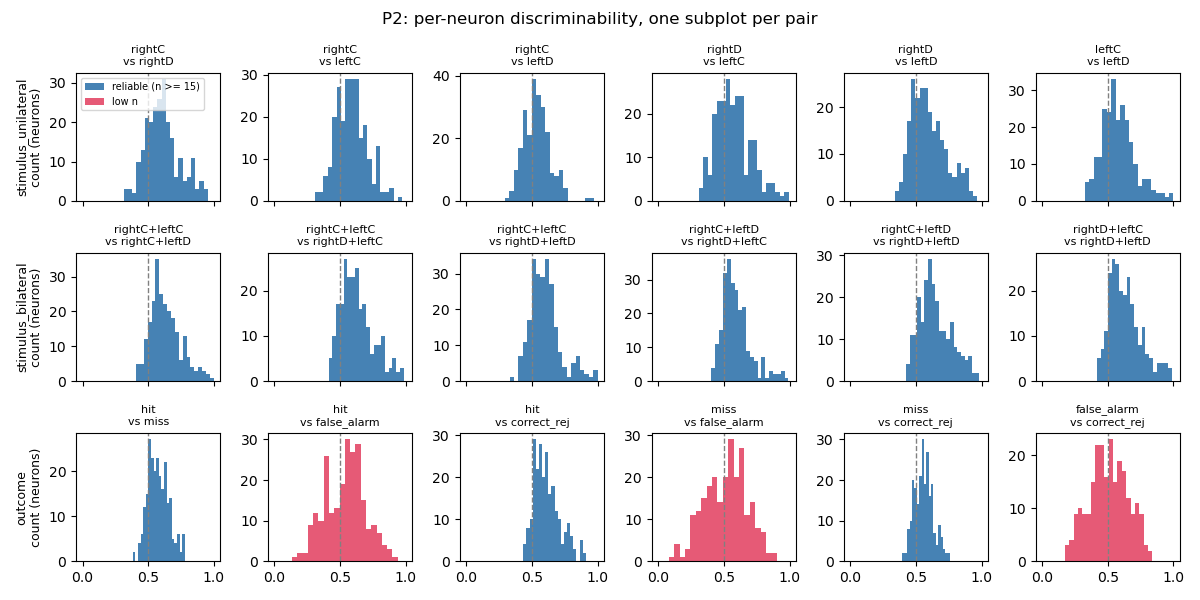

In [82]:
from itertools import combinations

n_pairs = 6  # 4 choose 2, per family
fig, axes = plt.subplots(len(CONDITION_FAMILIES), n_pairs, figsize=(12, 6), sharex=True)
for row_idx, (family, categories) in enumerate(CONDITION_FAMILIES.items()):
    family_df = temporal_discrim_all[temporal_discrim_all['variable'] == family]
    for col_idx, (a, b) in enumerate(combinations(categories, 2)):
        ax = axes[row_idx, col_idx]
        pair_df = family_df[(family_df['group_a'] == a) & (family_df['group_b'] == b)]
        reliable_vals = pair_df.loc[~pair_df['low_n'], 'auc']
        low_n_vals = pair_df.loc[pair_df['low_n'], 'auc']

        ax.hist(reliable_vals, bins=20, color='steelblue', label='reliable (n >= {})'.format(MIN_RELIABLE_N))
        ax.hist(low_n_vals, bins=20, color='crimson', alpha=0.7, label='low n')
        ax.axvline(0.5, color='gray', ls='--', lw=1)
        ax.set_title(f'{a}\nvs {b}', fontsize=8)
        if col_idx == 0:
            ax.set_ylabel(f'{family}\ncount (neurons)', fontsize=9)

axes[0, 0].legend(fontsize=7, loc='upper left')
fig.suptitle(f'{SESSION_ID}: per-neuron discriminability, one subplot per pair')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'summary_auc_distribution.png', dpi=150)
plt.show()


### 7b. Session-level summary table: one row per pair

Collapses each subplot above into three numbers: what fraction of the 198 neurons discriminate that pair better than chance (`frac_above_0_5`), what fraction discriminate it strongly (`frac_above_0_75`), and how many trials backed the comparison (`n_a`, `n_b`, `low_n`). Sorted so the most population-wide-discriminable pairs are on top — this is the table to scan first to answer "which stimuli/outcomes are most separable in this session," and the one saved per session for later cross-session comparison.

In [41]:
# pair_summary = (
#     temporal_discrim_all
#     .groupby(['variable', 'group_a', 'group_b'])
#     .agg(
#         n_neurons=('auc', 'size'),
#         frac_above_0_5=('auc', lambda x: (x > 0.5).mean()),
#         frac_above_0_75=('auc', lambda x: (x > 0.75).mean()),
#         n_a=('n_a', 'first'),
#         n_b=('n_b', 'first'),
#         low_n=('low_n', 'first'),
#     )
#     .reset_index()
#     .sort_values('frac_above_0_5', ascending=False)
# )

# pair_summary_path = RESULTS_DIR / f'temporal_pattern_pair_summary_{SESSION_ID}.csv'
# pair_summary.to_csv(pair_summary_path, index=False)
# print(f"Saved {len(pair_summary)} rows to {pair_summary_path}")

pair_summary

,variable,group_a,group_b,n_neurons,frac_above_0_5,frac_above_0_75,n_a,n_b,low_n
0,outcome,hit,correct_rej,239,0.916318,0.129707,196,382,False
1,stimulus_bilateral,rightD+leftC,rightD+leftD,239,0.903766,0.171548,96,122,False
2,stimulus_bilateral,rightC+leftD,rightD+leftD,239,0.903766,0.230126,124,122,False
3,stimulus_bilateral,rightC+leftC,rightC+leftD,239,0.899582,0.171548,122,124,False
4,stimulus_bilateral,rightC+leftC,rightD+leftC,239,0.866109,0.171548,122,96,False
5,stimulus_bilateral,rightC+leftD,rightD+leftC,239,0.857741,0.087866,124,96,False
6,stimulus_bilateral,rightC+leftC,rightD+leftD,239,0.841004,0.096234,122,122,False
7,outcome,hit,miss,239,0.836820,0.029289,196,48,False
8,stimulus_unilateral,rightC,rightD,239,0.799163,0.163180,44,29,False
9,outcome,miss,correct_rej,239,0.769874,0.008368,48,382,False


### 7c. What do the best examples actually look like?

The pair summary table above tells you *which* pairs are discriminable at the population level; this plots the trial-averaged firing-rate traces (same style as the Section 4 prototype) for the 10 single highest-AUC (neuron, pair) combos overall, restricted to reliable pairs. Useful as a sanity check — a genuinely discriminating neuron should show visibly diverging traces after touch onset, not just a high AUC number with no visible separation.

In [26]:
# top10 = reliable.sort_values('auc', ascending=False).head(10).reset_index(drop=True)

# fig, axes = plt.subplots(5, 2, figsize=(9, 14), sharex=True)
# for row, ax in zip(top10.itertuples(), axes.flat):
#     hemisphere, idx = row.neuron.split('_neuron_')
#     idx = int(idx)
#     tensor = lh_tensor if hemisphere == 'LH' else rh_tensor
#     labels = outcome if row.variable == 'outcome' else stimulus

#     X_neuron = tensor[:, :, idx]
#     X_a = X_neuron[labels == row.group_a]
#     X_b = X_neuron[labels == row.group_b]

#     ax.plot(bin_centers, X_a.mean(axis=0) / BIN_WIDTH_S, label=f'{row.group_a} (n={len(X_a)})')
#     ax.plot(bin_centers, X_b.mean(axis=0) / BIN_WIDTH_S, label=f'{row.group_b} (n={len(X_b)})')
#     ax.set_title(f'{row.neuron}  {row.variable}\nAUC={row.auc:.3f}, p={row.p_value:.4f}', fontsize=9)
#     ax.legend(fontsize=8)
#     ax.set_ylabel('firing rate (Hz)')

# for ax in axes[-1]:
#     ax.set_xlabel('time from trial start (s)')

# fig.suptitle(f'{SESSION_ID}: top 10 most discriminating neuron/pair combos')
# fig.tight_layout()
# # fig.savefig(FIGURES_DIR / 'top10_trial_averaged_traces.png', dpi=150)
# plt.show()


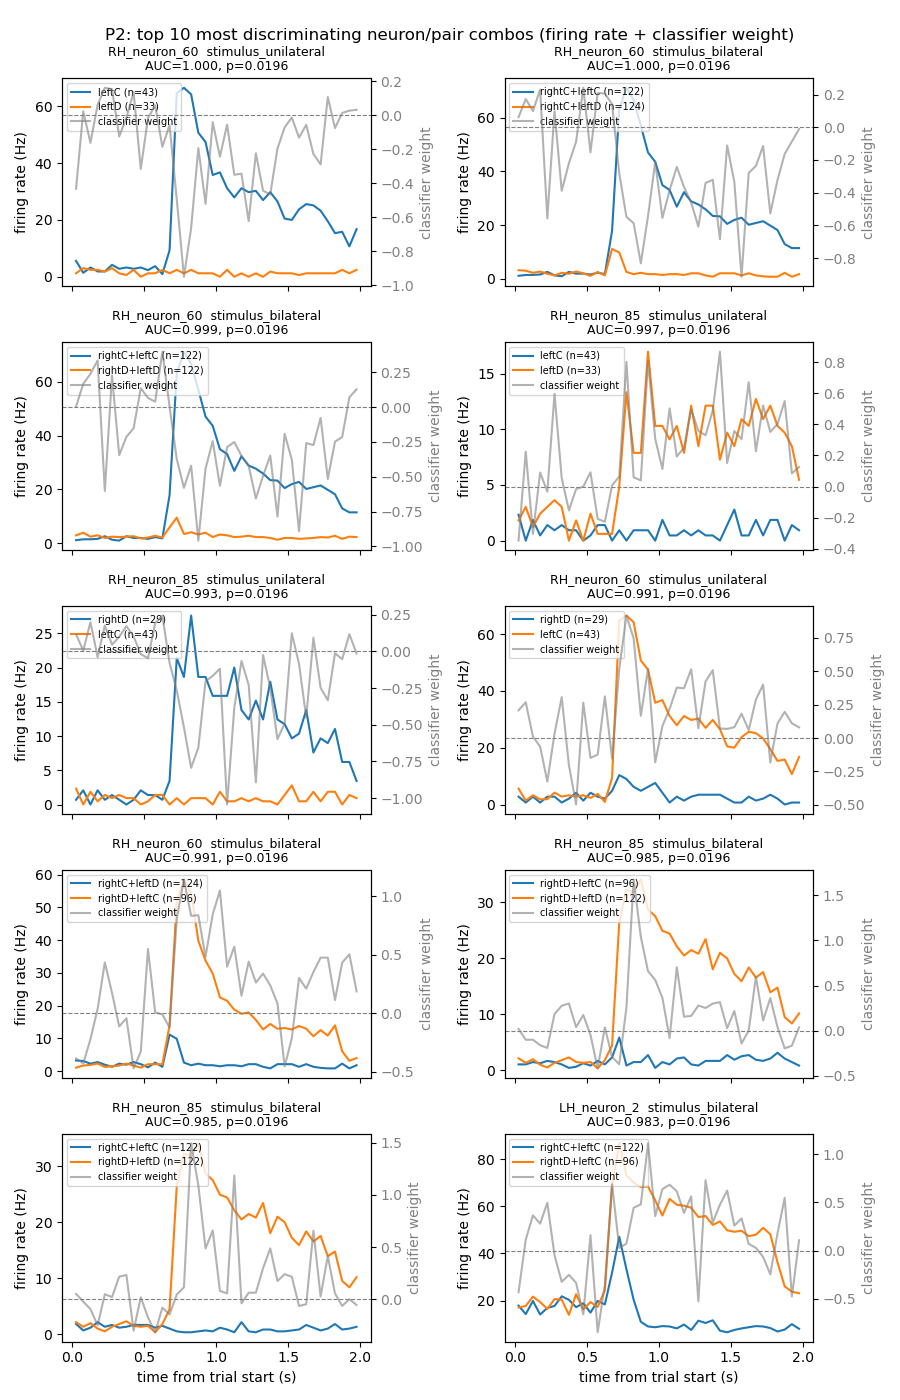

In [83]:
top10 = reliable.sort_values('auc', ascending=False).head(10).reset_index(drop=True)

fig, axes = plt.subplots(5, 2, figsize=(9, 14), sharex=True)
for row, ax in zip(top10.itertuples(), axes.flat):
    hemisphere, idx = row.neuron.split('_neuron_')
    idx = int(idx)
    tensor = lh_tensor if hemisphere == 'LH' else rh_tensor
    labels = outcome if row.variable == 'outcome' else stimulus

    X_neuron = tensor[:, :, idx]
    X_a = X_neuron[labels == row.group_a]
    X_b = X_neuron[labels == row.group_b]

    l1, = ax.plot(bin_centers, X_a.mean(axis=0) / BIN_WIDTH_S, color='C0', label=f'{row.group_a} (n={len(X_a)})')
    l2, = ax.plot(bin_centers, X_b.mean(axis=0) / BIN_WIDTH_S, color='C1', label=f'{row.group_b} (n={len(X_b)})')
    ax.set_title(f'{row.neuron}  {row.variable}\nAUC={row.auc:.3f}, p={row.p_value:.4f}', fontsize=9)
    ax.set_ylabel('firing rate (Hz)')

    weight_key = f'{row.neuron}__{row.variable}__{row.group_a}_vs_{row.group_b}'
    w = weights[weight_key]
    ax2 = ax.twinx()
    ax2.axhline(0, color='gray', lw=0.8, ls='--')
    l3, = ax2.plot(bin_centers, w, color='gray', alpha=0.6, label='classifier weight')
    ax2.set_ylabel('classifier weight', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

    ax.legend(handles=[l1, l2, l3], fontsize=7, loc='upper left')

for ax in axes[-1]:
    ax.set_xlabel('time from trial start (s)')

fig.suptitle(f'{SESSION_ID}: top 10 most discriminating neuron/pair combos (firing rate + classifier weight)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'top10_trial_averaged_traces.png', dpi=150)
plt.show()


Hit trials : 196
Touch latency — mean: 0.644 s  median: 0.642 s
Lick latency  — mean: 1.729 s  median: 1.793 s


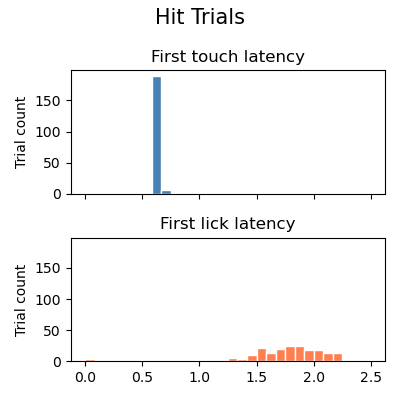

In [84]:
from tools.load_session import TIME_STEP

# ── Reference point: swap between trial start and stimulus onset ──────────
reference_frames = derived['trial_start_frames']   # trial start
# reference_frames = derived['trial_start_frames'] + 0.5        # stimulus onset

# ── Hit trials only ───────────────────────────────────────────────────────
hit_mask = np.array([o == 'hit' for o in derived['trial_outcome']])
# ── Latencies (seconds) ───────────────────────────────────────────────────
touch_latency_s = (derived['touch_onset_frames'][hit_mask] - reference_frames[hit_mask]) * TIME_STEP
lick_latency_s  = (derived['trial_first_lick_frames'][hit_mask]  - reference_frames[hit_mask]) * TIME_STEP

print(f"Hit trials : {hit_mask.sum()}")
print(f"Touch latency — mean: {np.nanmean(touch_latency_s):.3f} s  median: {np.nanmedian(touch_latency_s):.3f} s")
print(f"Lick latency  — mean: {np.nanmean(lick_latency_s):.3f} s  median: {np.nanmedian(lick_latency_s):.3f} s")

bins = np.linspace(0, 2.5, 31)  # 30 bins between 0 and 2.5

fig, axes = plt.subplots(2, 1, figsize=(4, 4), sharey=True, sharex=True)

axes[0].hist(touch_latency_s[~np.isnan(touch_latency_s)], bins=bins, color='steelblue', edgecolor='white')
axes[0].set_ylabel('Trial count')
axes[0].set_title('First touch latency')

axes[1].hist(lick_latency_s[~np.isnan(lick_latency_s)], bins=bins, color='coral', edgecolor='white')
axes[1].set_ylabel('Trial count')
axes[1].set_title('First lick latency')

plt.suptitle('Hit Trials', fontsize=15)
plt.tight_layout()
plt.savefig(f'figures/{SESSION_ID}_hit_trial_latencies.png', dpi=150)
plt.show()



## 8. Attach % shared variance (psv) from the pCCA-FA fit

`temporal_discrim_all`'s `LH_neuron_i`/`RH_neuron_i` indexes into **all** neurons in that hemisphere, but the saved pCCA-FA `metrics['psv']` arrays are indexed only over the **subset kept after filtering** (fsrs/rate thresholds) — a naive name match would silently misattribute values. This cell uses the saved `lh_neuron_mask`/`rh_neuron_mask` (from `results/{SESSION_ID}_w0.0-1.0.joblib`) to place each kept neuron's psv value back at its correct all-neuron position, leaving `NaN` for neurons that were excluded from the pCCA-FA fit entirely.

This is also where the final `temporal_discrim_all` gets saved to disk (`results/temporal_pattern_discriminability_{SESSION_ID}.csv`) — now that every column (including `psv_across`/`psv_within`) is populated, this is the one canonical save for this table; nothing upstream saves it early.

In [38]:
# from tools.neuron_behavior_analysis import load_saved_session

# PSV_SESSION_ID = f'{SESSION_ID}_w0.0-1.0'  # window used for the pCCA-FA fit
# payload = load_saved_session(PSV_SESSION_ID)
# metrics = payload['metrics']
# pcca_input_data = payload['pcca_input_data']

# def psv_lookup(hemisphere):
#     """(n_hemisphere_neurons,) arrays of psv_across / psv_within, NaN for
#     neurons excluded from the pCCA-FA fit. Index i matches the tensor's
#     neuron axis (both derive from session_data['loc_{lh,rh}_mask'] in the
#     same order)."""
#     neuron_mask = pcca_input_data[f'{hemisphere.lower()}_neuron_mask']
#     suffix = '_1' if hemisphere == 'LH' else '_2'
#     psv_across_kept = metrics['psv']['psv_W' + suffix]
#     psv_within_kept = metrics['psv']['psv_L' + suffix]

#     psv_across = np.full(len(neuron_mask), np.nan)
#     psv_within = np.full(len(neuron_mask), np.nan)
#     psv_across[neuron_mask] = psv_across_kept
#     psv_within[neuron_mask] = psv_within_kept
#     return psv_across, psv_within

# lh_psv_across, lh_psv_within = psv_lookup('LH')
# rh_psv_across, rh_psv_within = psv_lookup('RH')

# def get_psv(neuron_name):
#     hemisphere, idx = neuron_name.split('_neuron_')
#     idx = int(idx)
#     return (lh_psv_across[idx], lh_psv_within[idx]) if hemisphere == 'LH' \
#         else (rh_psv_across[idx], rh_psv_within[idx])

# psv_values = temporal_discrim_all['neuron'].apply(get_psv)
# temporal_discrim_all['psv_across'] = psv_values.apply(lambda t: t[0])
# temporal_discrim_all['psv_within'] = psv_values.apply(lambda t: t[1])

# # out_path = RESULTS_DIR / f'temporal_pattern_discriminability_{SESSION_ID}.csv'
# # temporal_discrim_all.to_csv(out_path, index=False)
# print(f"Saved {len(temporal_discrim_all)} rows (with psv_across/psv_within) to {out_path}")

# temporal_discrim_all.head()

### 8a. Does *any* strong discriminability track shared variance?

For each neuron, take its best (max) AUC across every reliable pair from any family (stimulus or outcome), then scatter that against `psv_across`/`psv_within`, with a Spearman rho as the summary statistic. This asks the broadest version of the question: is being good at discriminating *something* related to carrying more shared variance? (Section 8b below asks the narrower, pair-specific version of the same question.)

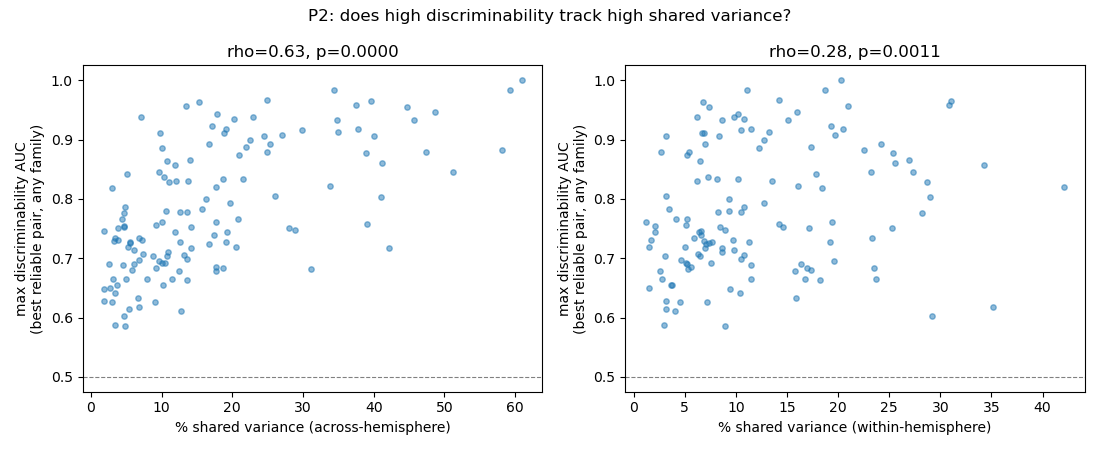

In [85]:
neuron_summary = (
    temporal_discrim_all[~temporal_discrim_all['low_n']]
    .groupby('neuron')
    .agg(
        max_auc=('auc', 'max'),
        psv_across=('psv_across', 'first'),
        psv_within=('psv_within', 'first'),
        hemisphere=('hemisphere', 'first'),
    )
    .reset_index()
    .dropna(subset=['psv_across', 'psv_within'])  # drop neurons excluded from the pCCA-FA fit
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, psv_col, label in zip(axes, ['psv_across', 'psv_within'], ['across-hemisphere', 'within-hemisphere']):
    rho, p = spearmanr(neuron_summary[psv_col], neuron_summary['max_auc'])
    ax.scatter(neuron_summary[psv_col], neuron_summary['max_auc'], alpha=0.5, s=15)
    ax.axhline(0.5, color='gray', ls='--', lw=0.8)
    ax.set_xlabel(f'% shared variance ({label})')
    ax.set_ylabel('max discriminability AUC\n(best reliable pair, any family)')
    ax.set_title(f'rho={rho:.2f}, p={p:.4f}')

fig.suptitle(f'{SESSION_ID}: does high discriminability track high shared variance?')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'psv_vs_max_discriminability.png', dpi=150)
plt.show()

### 8b. Does discriminability for one specific pair track shared variance? (Reward vs Null stimuli)

Same test as 8a, but for a single named pair (`GROUP_A` vs `GROUP_B`, set below) instead of each neuron's best-case AUC across every family — this is the more literal version of the question, since it isolates one specific comparison rather than mixing in whichever pair happened to be each neuron's best. Change `GROUP_A`/`GROUP_B` to any pair in `temporal_discrim_all` to re-run for a different comparison.

In [87]:
print(f' Rewarded stimuli: {set([derived["trial_stimulus"][i] for i, o in enumerate(derived["trial_outcome"]) if o in ["hit", "miss"]])}')
print(f' Unrewarded stimuli: {set([derived["trial_stimulus"][i] for i, o in enumerate(derived["trial_outcome"]) if o in ["false_alarm", "correct_rej"]])}')


 Rewarded stimuli: {'rightC+leftC', 'rightD+leftD'}
 Unrewarded stimuli: {'rightC+leftD', 'rightD+leftC', 'leftC', 'leftD', 'none', 'rightC', 'rightD'}


In [70]:
print(f"temporal_discrim_all.group_a.unique(): {temporal_discrim_all.group_a.unique()}")
print(f"temporal_discrim_all.group_b.unique(): {temporal_discrim_all.group_b.unique()}")

temporal_discrim_all.group_a.unique(): ['rightC' 'rightD' 'leftC' 'rightC+leftC' 'rightC+leftD' 'rightD+leftC'
 'hit' 'miss' 'false_alarm']
temporal_discrim_all.group_b.unique(): ['rightD' 'leftC' 'leftD' 'rightC+leftD' 'rightD+leftC' 'rightD+leftD'
 'miss' 'false_alarm' 'correct_rej']


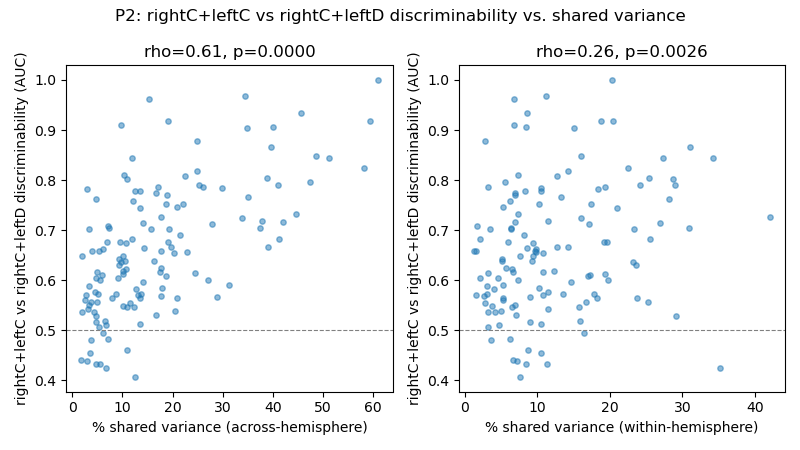

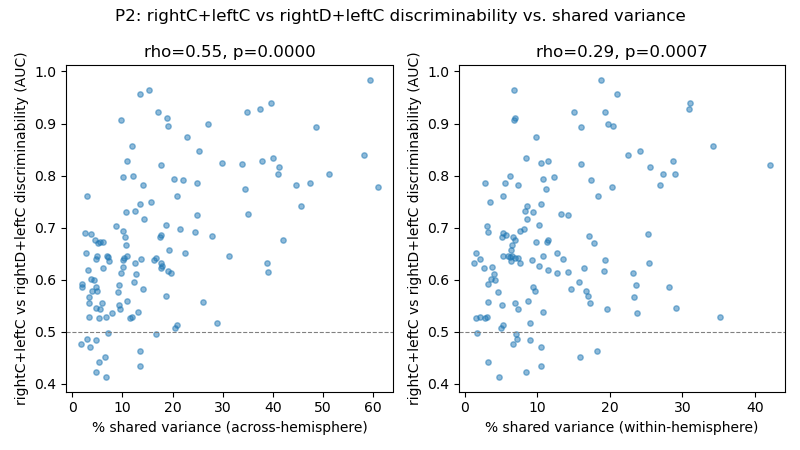

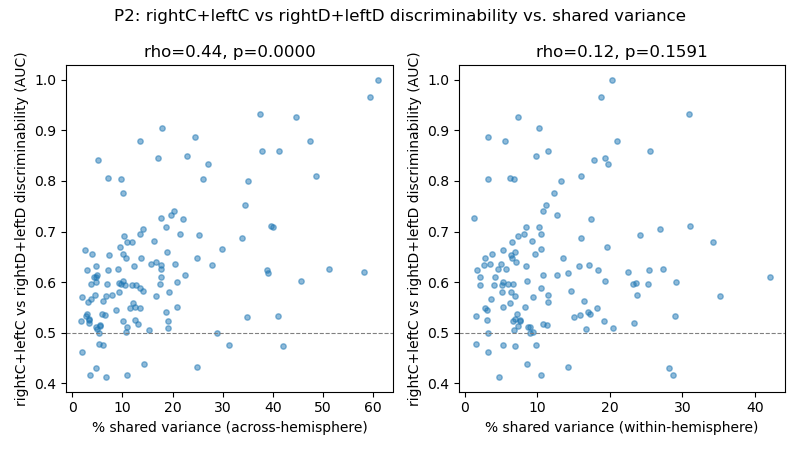

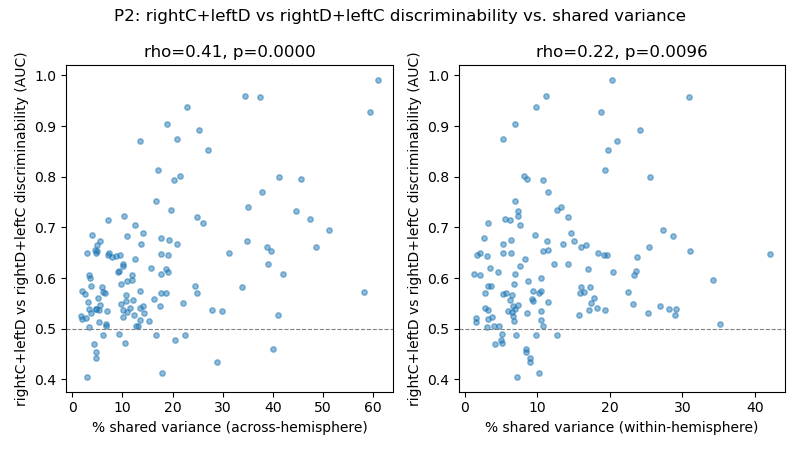

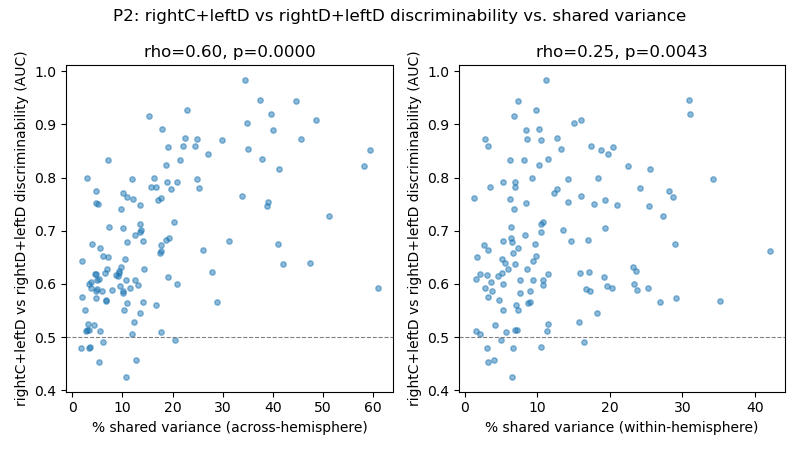

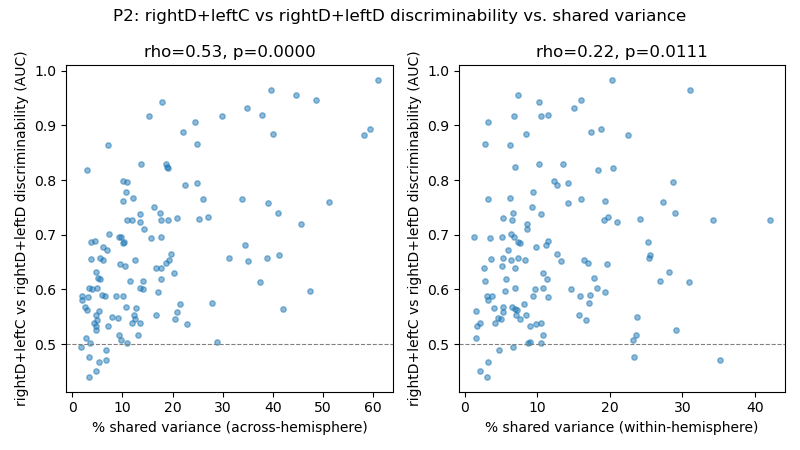

In [86]:
# Loop through all bilateral stimulus pairs
GROUPS = [
    ('rightC+leftC', 'rightC+leftD'),
    ('rightC+leftC', 'rightD+leftC'),
    ('rightC+leftC', 'rightD+leftD'),
    ('rightC+leftD', 'rightD+leftC'),
    ('rightC+leftD', 'rightD+leftD'),
    ('rightD+leftC', 'rightD+leftD'),
    # add other bilateral stimulus pairs as needed
]
for GROUP_A, GROUP_B in GROUPS:
    # GROUP_A, GROUP_B = 'rightC+leftD', 'rightD+leftD'

    # named pair_neuron_psv, not pair_summary, to avoid overwriting the
    # session-level fraction summary computed in Section 7b
    pair_neuron_psv = (
        temporal_discrim_all[
            (temporal_discrim_all['group_a'] == GROUP_A) &
            (temporal_discrim_all['group_b'] == GROUP_B) &
            (~temporal_discrim_all['low_n'])
        ]
        [['neuron', 'hemisphere', 'auc', 'psv_across', 'psv_within']]
        .dropna(subset=['psv_across', 'psv_within'])  # drop neurons excluded from the pCCA-FA fit
    )

    fig, axes = plt.subplots(1, 2, figsize=(8, 4.5))
    for ax, psv_col, label in zip(axes, ['psv_across', 'psv_within'], ['across-hemisphere', 'within-hemisphere']):
        rho, p = spearmanr(pair_neuron_psv[psv_col], pair_neuron_psv['auc'])
        ax.scatter(pair_neuron_psv[psv_col], pair_neuron_psv['auc'], alpha=0.5, s=15)
        ax.axhline(0.5, color='gray', ls='--', lw=0.8)
        ax.set_xlabel(f'% shared variance ({label})')
        ax.set_ylabel(f'{GROUP_A} vs {GROUP_B} discriminability (AUC)')
        ax.set_title(f'rho={rho:.2f}, p={p:.4f}')

    fig.suptitle(f'{SESSION_ID}: {GROUP_A} vs {GROUP_B} discriminability vs. shared variance')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f'psv_vs_discriminability_{GROUP_A}_vs_{GROUP_B}.png', dpi=150)
    plt.show()

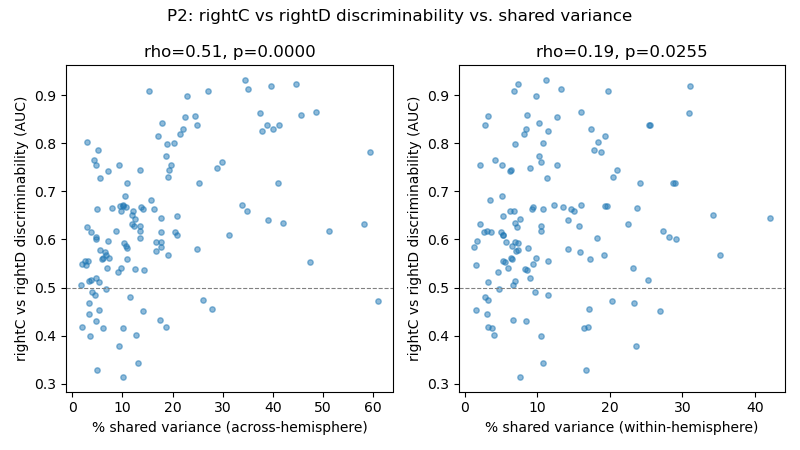

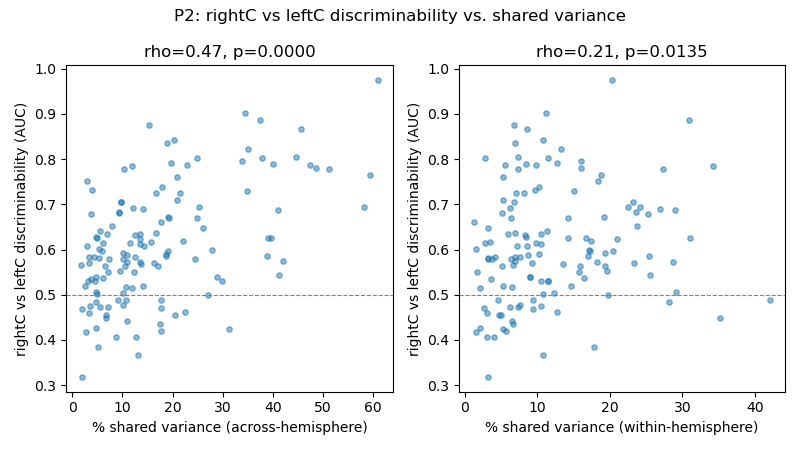

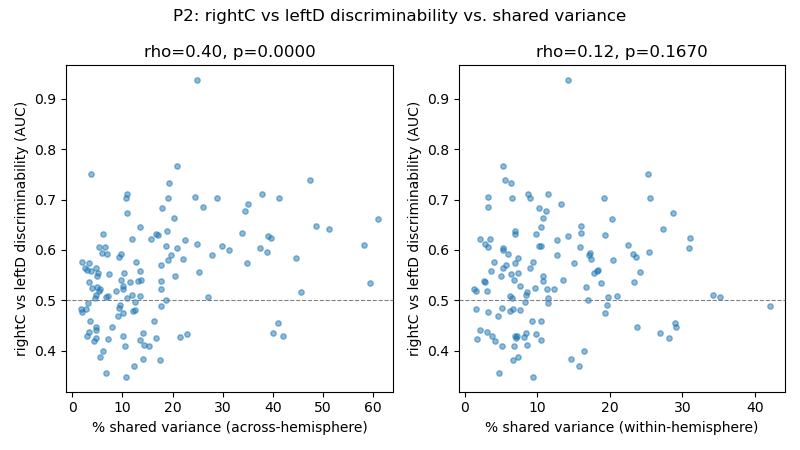

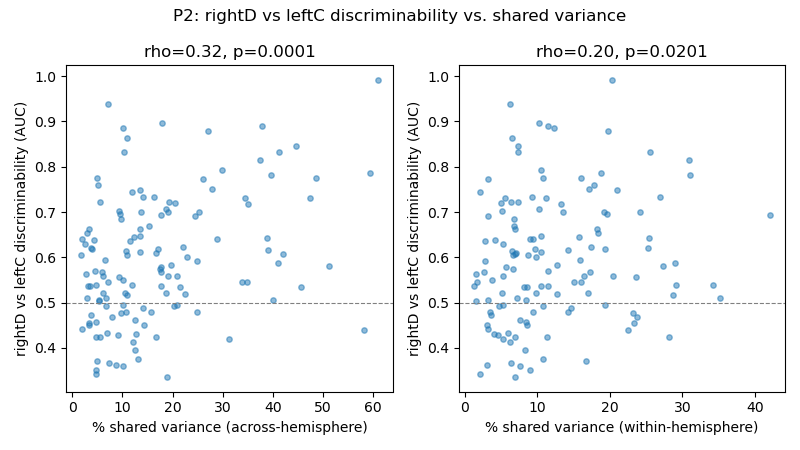

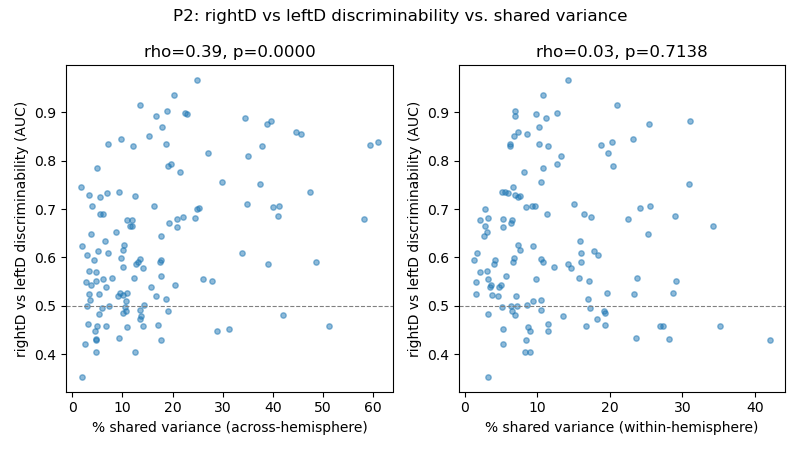

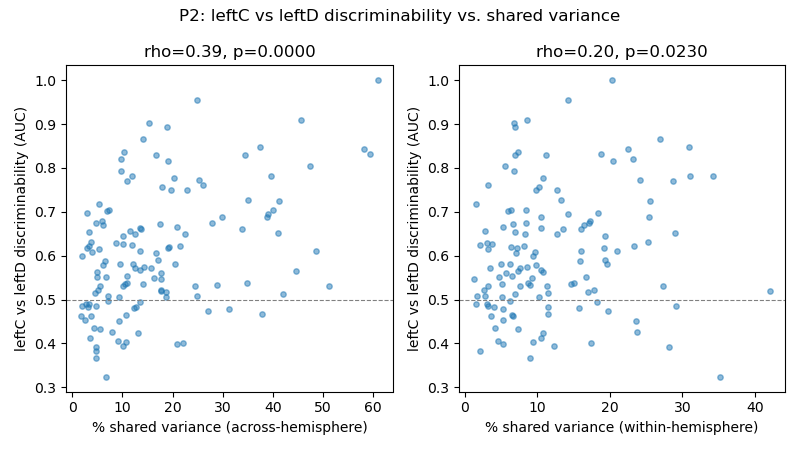

In [88]:
# Loop through all unilateral stimulus pairs
GROUPS = [
    ('rightC', 'rightD'),
    ('rightC', 'leftC'),
    ('rightC', 'leftD'),
    ('rightD', 'leftC'),
    ('rightD', 'leftD'),
    ('leftC', 'leftD'),

    # add other unilateral stimulus pairs as needed
]
for GROUP_A, GROUP_B in GROUPS:
    # GROUP_A, GROUP_B = 'rightC+leftD', 'rightD+leftD'

    # named pair_neuron_psv, not pair_summary, to avoid overwriting the
    # session-level fraction summary computed in Section 7b
    pair_neuron_psv = (
        temporal_discrim_all[
            (temporal_discrim_all['group_a'] == GROUP_A) &
            (temporal_discrim_all['group_b'] == GROUP_B) &
            (~temporal_discrim_all['low_n'])
        ]
        [['neuron', 'hemisphere', 'auc', 'psv_across', 'psv_within']]
        .dropna(subset=['psv_across', 'psv_within'])  # drop neurons excluded from the pCCA-FA fit
    )

    fig, axes = plt.subplots(1, 2, figsize=(8, 4.5))
    for ax, psv_col, label in zip(axes, ['psv_across', 'psv_within'], ['across-hemisphere', 'within-hemisphere']):
        rho, p = spearmanr(pair_neuron_psv[psv_col], pair_neuron_psv['auc'])
        ax.scatter(pair_neuron_psv[psv_col], pair_neuron_psv['auc'], alpha=0.5, s=15)
        ax.axhline(0.5, color='gray', ls='--', lw=0.8)
        ax.set_xlabel(f'% shared variance ({label})')
        ax.set_ylabel(f'{GROUP_A} vs {GROUP_B} discriminability (AUC)')
        ax.set_title(f'rho={rho:.2f}, p={p:.4f}')

    fig.suptitle(f'{SESSION_ID}: {GROUP_A} vs {GROUP_B} discriminability vs. shared variance')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f'psv_vs_discriminability_{GROUP_A}_vs_{GROUP_B}.png', dpi=150)
    plt.show()